In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kushagrabharadwaj","key":"8758c1243566114a0918e5ba0c3e8172"}'}

In [ ]:
! mkdir ~/.kaggle

In [ ]:
! cp kaggle.json ~/.kaggle/

In [ ]:
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:

! kaggle datasets list

ref                                                           title                                            size  lastUpdated          downloadCount  voteCount  usabilityRating  
------------------------------------------------------------  ----------------------------------------------  -----  -------------------  -------------  ---------  ---------------  
sudarshan24byte/online-food-dataset                           Online Food Dataset                               3KB  2024-03-02 18:50:30          24868        495  0.9411765        
sukhmandeepsinghbrar/most-subscribed-youtube-channel          Most Subscribed YouTube Channel                   1KB  2024-04-10 20:33:05            789         30  1.0              
sanyamgoyal401/customer-purchases-behaviour-dataset           Customer Purchases Behaviour Dataset              1MB  2024-04-06 18:42:01           1314         34  1.0              
mohdshahnawazaadil/credit-card-dataset                        Credit Card Dataset         

In [ ]:
!kaggle datasets download -d kushagrabharadwaj/kushagra-brain-tumor

 89% 41.0M/45.9M [00:00<00:00, 91.7MB/s]
100% 45.9M/45.9M [00:00<00:00, 90.7MB/s]


In [ ]:
!unzip kushagra-brain-tumor.zip

Streaming output truncated to the last 5000 lines.
  inflating: Tumor_1/meningioma_1/Tr-me_0096.jpg  
  inflating: Tumor_1/meningioma_1/Tr-me_0097.jpg  
  inflating: Tumor_1/meningioma_1/Tr-me_0098.jpg  
  inflating: Tumor_1/meningioma_1/Tr-me_0099.jpg  
  inflating: Tumor_1/meningioma_1/Tr-me_0100.jpg  
  inflating: Tumor_1/meningioma_1/Tr-me_0101.jpg  
  inflating: Tumor_1/meningioma_1/Tr-me_0102.jpg  
  inflating: Tumor_1/meningioma_1/Tr-me_0103.jpg  
  inflating: Tumor_1/meningioma_1/Tr-me_0104.jpg  
  inflating: Tumor_1/meningioma_1/Tr-me_0105.jpg  
  inflating: Tumor_1/meningioma_1/Tr-me_0106.jpg  
  inflating: Tumor_1/meningioma_1/Tr-me_0107.jpg  
  inflating: Tumor_1/meningioma_1/Tr-me_0108.jpg  
  inflating: Tumor_1/meningioma_1/Tr-me_0109.jpg  
  inflating: Tumor_1/meningioma_1/Tr-me_0110.jpg  
  inflating: Tumor_1/meningioma_1/Tr-me_0111.jpg  
  inflating: Tumor_1/meningioma_1/Tr-me_0112.jpg  
  inflating: Tumor_1/meningioma_1/Tr-me_0113.jpg  
  inflating: Tumor_1/meningioma

In [ ]:

pip install split-folders[full]

In [ ]:
import splitfolders
input_folder= "/content/Tumor_1"
splitfolders.ratio(input_folder, output="dataset",
                   seed=42, ratio=(.7, .2, .1),
                   group_prefix=None)

Copying files: 7023 files [00:00, 8070.08 files/s]


In [ ]:
import os
for dirpath, dirnames, filenames in os.walk("dataset"):
 print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 3 directories and 0 images in 'dataset'.
There are 4 directories and 0 images in 'dataset/train'.
There are 0 directories and 1400 images in 'dataset/train/notumor_1'.
There are 0 directories and 1151 images in 'dataset/train/meningioma_1'.
There are 0 directories and 1134 images in 'dataset/train/glioma_1'.
There are 0 directories and 1229 images in 'dataset/train/pituitary_1'.
There are 4 directories and 0 images in 'dataset/val'.
There are 0 directories and 400 images in 'dataset/val/notumor_1'.
There are 0 directories and 329 images in 'dataset/val/meningioma_1'.
There are 0 directories and 324 images in 'dataset/val/glioma_1'.
There are 0 directories and 351 images in 'dataset/val/pituitary_1'.
There are 4 directories and 0 images in 'dataset/test'.
There are 0 directories and 200 images in 'dataset/test/notumor_1'.
There are 0 directories and 165 images in 'dataset/test/meningioma_1'.
There are 0 directories and 163 images in 'dataset/test/glioma_1'.
There are 0 directo

In [ ]:
! ls -la  dataset

total 20
drwxr-xr-x 5 root root 4096 Apr 13 16:09 .
drwxr-xr-x 1 root root 4096 Apr 13 16:09 ..
drwxr-xr-x 6 root root 4096 Apr 13 16:09 test
drwxr-xr-x 6 root root 4096 Apr 13 16:09 train
drwxr-xr-x 6 root root 4096 Apr 13 16:09 val


In [ ]:
import pathlib
import numpy as np
data_dir = pathlib.Path("dataset/train")
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['glioma_1' 'meningioma_1' 'notumor_1' 'pituitary_1']


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_image(target_dir, target_class):

  target_folder = target_dir+target_class


  random_image = random.sample(os.listdir(target_folder), 1)

  img = mpimg.imread(target_folder + "/" + random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off");

  print(f"Image shape: {img.shape}")

  return img

Image shape: (224, 224, 3)


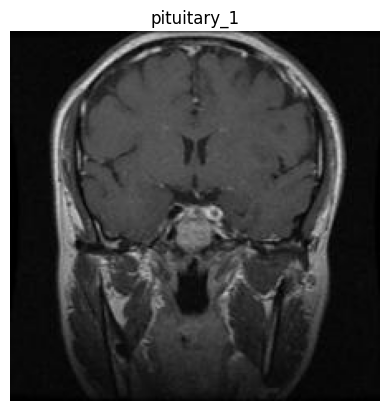

In [ ]:
img = view_random_image(target_dir="dataset/train/",
                        target_class="pituitary_1")#View a random image from the training dataset

In [ ]:
img.shape

(224, 224, 3)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set the seed
tf.random.set_seed(42)

train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


# Setup the train and test directories
train_dir = "/content/dataset/train"
test_dir = "/content/dataset/test"
val_dir = "/content/dataset/val"


train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size=32,
                                               target_size=(224, 224),
                                               class_mode="categorical",
                                               seed=42)

valid_data = valid_datagen.flow_from_directory(val_dir,
                                               batch_size=32,
                                               target_size=(224, 224),
                                               class_mode="categorical",
                                               seed=42)

test_data = test_datagen.flow_from_directory(test_dir,
                                               batch_size=32,
                                               target_size=(224, 224),
                                               class_mode="categorical",
                                               seed=42)

Found 4914 images belonging to 4 classes.
Found 1404 images belonging to 4 classes.
Found 705 images belonging to 4 classes.


##MODEL-13


In [ ]:
import tensorflow as tf

model_13 = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation="relu", input_shape=(224, 224, 3)),
  tf.keras.layers.Conv2D(64, 3, activation="relu"),
  tf.keras.layers.MaxPool2D(pool_size=2),
  tf.keras.layers.Conv2D(32, 3, activation="relu"),
  tf.keras.layers.Conv2D(32, 3, activation="relu"),
  tf.keras.layers.MaxPool2D(pool_size=2),
   tf.keras.layers.Conv2D(16, 3, activation="relu"),
  tf.keras.layers.MaxPool2D(pool_size=2),
  tf.keras.layers.Flatten(),
   tf.keras.layers.Dropout(0.4),
  tf.keras.layers.Dense(512, activation='relu'),
  tf.keras.layers.Dense(256, activation='relu'),
  tf.keras.layers.Dropout(0.4),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dense(32, activation='relu'),
  tf.keras.layers.Dense(4, activation="softmax")
])


model_13.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["accuracy"])

In [ ]:
model_13.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_20 (Conv2D)          (None, 222, 222, 64)      1792      
                                                                 
 conv2d_21 (Conv2D)          (None, 220, 220, 64)      36928     
                                                                 
 max_pooling2d_12 (MaxPooli  (None, 110, 110, 64)      0         
 ng2D)                                                           
                                                                 
 conv2d_22 (Conv2D)          (None, 108, 108, 32)      18464     
                                                                 
 conv2d_23 (Conv2D)          (None, 106, 106, 32)      9248      
                                                                 
 max_pooling2d_13 (MaxPooli  (None, 53, 53, 32)        0         
 ng2D)                                                

In [ ]:
history_13 = model_13.fit(train_data,
                        epochs=20,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Epoch 1/20
154/154 [==============================] - 28s 162ms/step - loss: 0.8002 - accuracy: 0.6569 - val_loss: 0.5515 - val_accuracy: 0.7806
Epoch 2/20
154/154 [==============================] - 25s 161ms/step - loss: 0.4720 - accuracy: 0.8107 - val_loss: 0.3894 - val_accuracy: 0.8604
Epoch 3/20
154/154 [==============================] - 25s 160ms/step - loss: 0.3284 - accuracy: 0.8730 - val_loss: 0.3024 - val_accuracy: 0.8896
Epoch 4/20
154/154 [==============================] - 25s 162ms/step - loss: 0.2196 - accuracy: 0.9170 - val_loss: 0.2533 - val_accuracy: 0.9266
Epoch 5/20
154/154 [==============================] - 25s 159ms/step - loss: 0.1709 - accuracy: 0.9412 - val_loss: 0.2211 - val_accuracy: 0.9316
Epoch 6/20
154/154 [==============================] - 24s 156ms/step - loss: 0.1222 - accuracy: 0.9640 - val_loss: 0.2523 - val_accuracy: 0.9330
Epoch 7/20
154/154 [==============================] - 25s 161ms/step - loss: 0.1187 - accuracy: 0.9636 - val_loss: 0.2009 - val_ac

In [ ]:
model_13.evaluate(test_data)

23/23 [==============================] - 2s 61ms/step - loss: 0.2687 - accuracy: 0.9546


[0.2687343657016754, 0.9546099305152893]

In [ ]:
def plot_loss_curves(history):
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

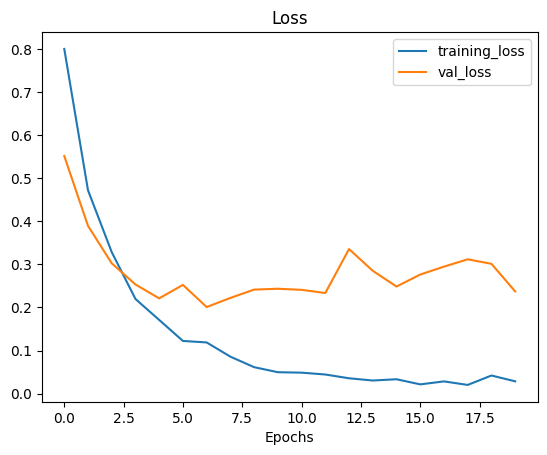

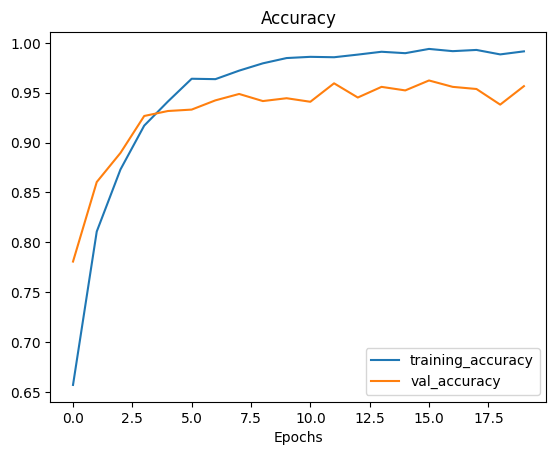

In [ ]:
plot_loss_curves(history_13)

1/1 [==============================] - 0s 16ms/step


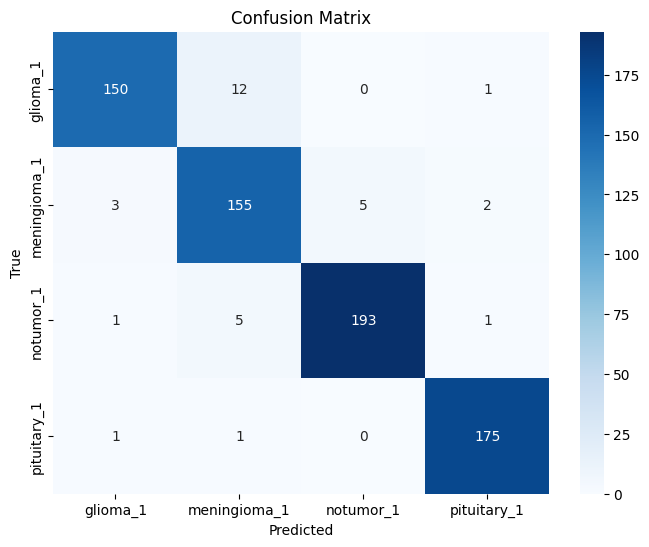

In [ ]:
import os
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import MobileNetV2  # Replace this with your chosen CNN model



def load_and_prep_image(filename, img_shape=500):
  """
  Reads an image from filename, turns it into a tensor
  and reshapes it to (img_shape, img_shape, colour_channel).
  """
  # Read in target file (an image)
  img = tf.io.read_file(filename)

  # Decode the read file into a tensor & ensure 3 colour channels
  # (our model is trained on images with 3 colour channels and sometimes images have 4 colour channels)
  img = tf.image.decode_image(img, channels=3)

  # Resize the image (to the same size our model was trained on)
  img = tf.image.resize(img, size = [img_shape, img_shape])

  # Rescale the image (get all values between 0 and 1)
  img = img/255.
  return img



# Path to the directory containing your data
data_directory = '/content/dataset/test/'

# Get class names from folder names
class_names = sorted(os.listdir(data_directory))

# Mapping folder names to class labels
label_map = {class_name: i for i, class_name in enumerate(class_names)}

# Initialize lists to store true and predicted labels
true_labels = []
predicted_labels = []

# Iterate through the folders and files to generate labels and predictions
for class_label, class_name in enumerate(class_names):
    class_folder = os.path.join(data_directory, class_name)
    for file_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, file_name)
        img = image.load_img(img_path, target_size=(224, 224))  # Adjust target size as needed
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = img_array/255.
#         img_array = preprocess_input(img_array)  # Preprocess input based on the chosen model

        # Predict class label using your CNN model
        predictions = model_13.predict(img_array)
        predicted_class = np.argmax(predictions)

        # Assign true label based on folder name
        true_labels.append(class_label)
        predicted_labels.append(predicted_class)

# Convert lists to numpy arrays
true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# Compute confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Display the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

##MODEL-14

In [ ]:
import tensorflow as tf

model_f = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation="relu", input_shape=(224, 224, 3)),
  tf.keras.layers.Conv2D(64, 3, activation="relu"),
  tf.keras.layers.MaxPool2D(pool_size=2),
  tf.keras.layers.Conv2D(32, 3, activation="relu"),
  tf.keras.layers.Conv2D(32, 3, activation="relu"),
  tf.keras.layers.MaxPool2D(pool_size=2),
   tf.keras.layers.Conv2D(16, 3, activation="relu"),
  tf.keras.layers.MaxPool2D(pool_size=2),
  tf.keras.layers.Flatten(),
   tf.keras.layers.Dropout(0.5),
  tf.keras.layers.Dense(512, activation='relu'),
  tf.keras.layers.Dense(256, activation='relu'),
  tf.keras.layers.Dropout(0.5),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dense(32, activation='relu'),
  tf.keras.layers.Dense(4, activation="softmax")
])


model_f.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["accuracy"])

history_f = model_f.fit(train_data,
                        epochs=20,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Epoch 1/20
154/154 [==============================] - 44s 196ms/step - loss: 0.8617 - accuracy: 0.6117 - val_loss: 0.5312 - val_accuracy: 0.8020
Epoch 2/20
154/154 [==============================] - 24s 158ms/step - loss: 0.5033 - accuracy: 0.7985 - val_loss: 0.4172 - val_accuracy: 0.8333
Epoch 3/20
154/154 [==============================] - 25s 161ms/step - loss: 0.3679 - accuracy: 0.8551 - val_loss: 0.3126 - val_accuracy: 0.8846
Epoch 4/20
154/154 [==============================] - 25s 162ms/step - loss: 0.2880 - accuracy: 0.8950 - val_loss: 0.3281 - val_accuracy: 0.8811
Epoch 5/20
154/154 [==============================] - 25s 163ms/step - loss: 0.2132 - accuracy: 0.9196 - val_loss: 0.2984 - val_accuracy: 0.8882
Epoch 6/20
154/154 [==============================] - 25s 162ms/step - loss: 0.1669 - accuracy: 0.9392 - val_loss: 0.2142 - val_accuracy: 0.9288
Epoch 7/20
154/154 [==============================] - 25s 162ms/step - loss: 0.1413 - accuracy: 0.9522 - val_loss: 0.2297 - val_ac

In [ ]:
model_14.summary()

NameError: name 'model_14' is not defined

In [ ]:
model_14.evaluate(test_data)

23/23 [==============================] - 2s 71ms/step - loss: 0.3106 - accuracy: 0.9546


[0.3106461465358734, 0.9546099305152893]

In [ ]:
model_14.save("model_14.h5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
def plot_loss_curves(history):
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

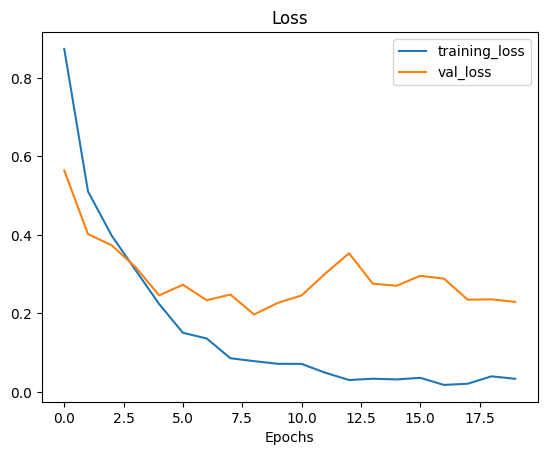

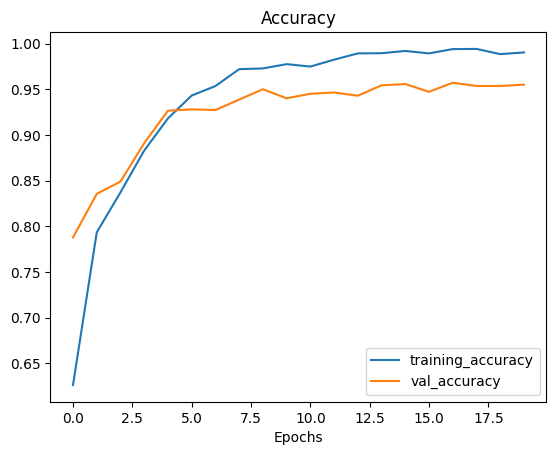

In [ ]:
plot_loss_curves(history_14)

#Confusion matrix of Testing data

1/1 [==============================] - 0s 17ms/step


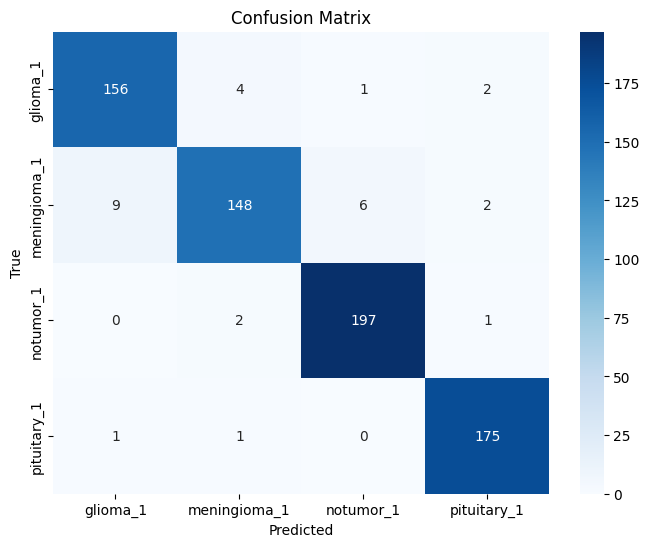

In [ ]:
import os
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import MobileNetV2  # Replace this with your chosen CNN model



def load_and_prep_image(filename, img_shape=500):
  """
  Reads an image from filename, turns it into a tensor
  and reshapes it to (img_shape, img_shape, colour_channel).
  """
  # Read in target file (an image)
  img = tf.io.read_file(filename)

  # Decode the read file into a tensor & ensure 3 colour channels
  # (our model is trained on images with 3 colour channels and sometimes images have 4 colour channels)
  img = tf.image.decode_image(img, channels=3)

  # Resize the image (to the same size our model was trained on)
  img = tf.image.resize(img, size = [img_shape, img_shape])

  # Rescale the image (get all values between 0 and 1)
  img = img/255.
  return img



# Path to the directory containing your data
data_directory = '/content/dataset/test/'

# Get class names from folder names
class_names = sorted(os.listdir(data_directory))

# Mapping folder names to class labels
label_map = {class_name: i for i, class_name in enumerate(class_names)}

# Initialize lists to store true and predicted labels
true_labels = []
predicted_labels = []

# Iterate through the folders and files to generate labels and predictions
for class_label, class_name in enumerate(class_names):
    class_folder = os.path.join(data_directory, class_name)
    for file_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, file_name)
        img = image.load_img(img_path, target_size=(224, 224))  # Adjust target size as needed
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = img_array/255.
#         img_array = preprocess_input(img_array)  # Preprocess input based on the chosen model

        # Predict class label using your CNN model
        predictions = model_14.predict(img_array)
        predicted_class = np.argmax(predictions)

        # Assign true label based on folder name
        true_labels.append(class_label)
        predicted_labels.append(predicted_class)

# Convert lists to numpy arrays
true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# Compute confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Display the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Print classification report
from sklearn.metrics import confusion_matrix, classification_report
print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=test_data.class_indices.keys()))

Classification Report:
              precision    recall  f1-score   support

    glioma_1       0.94      0.96      0.95       163
meningioma_1       0.95      0.90      0.92       165
   notumor_1       0.97      0.98      0.98       200
 pituitary_1       0.97      0.99      0.98       177

    accuracy                           0.96       705
   macro avg       0.96      0.96      0.96       705
weighted avg       0.96      0.96      0.96       705



#Confusion Matrix of Training data

1/1 [==============================] - 0s 25ms/step


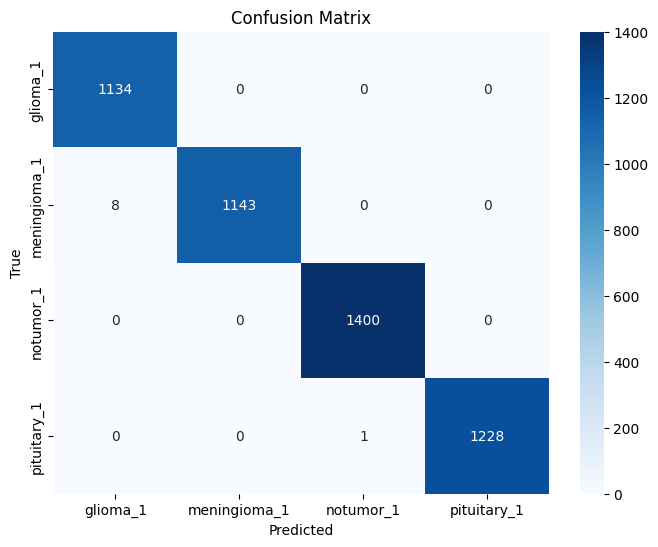

In [ ]:
import os
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import MobileNetV2  # Replace this with your chosen CNN model



def load_and_prep_image(filename, img_shape=500):
  """
  Reads an image from filename, turns it into a tensor
  and reshapes it to (img_shape, img_shape, colour_channel).
  """
  # Read in target file (an image)
  img = tf.io.read_file(filename)

  # Decode the read file into a tensor & ensure 3 colour channels
  # (our model is trained on images with 3 colour channels and sometimes images have 4 colour channels)
  img = tf.image.decode_image(img, channels=3)

  # Resize the image (to the same size our model was trained on)
  img = tf.image.resize(img, size = [img_shape, img_shape])

  # Rescale the image (get all values between 0 and 1)
  img = img/255.
  return img



# Path to the directory containing your data
data_directory = '/content/dataset/train'

# Get class names from folder names
class_names = sorted(os.listdir(data_directory))

# Mapping folder names to class labels
label_map = {class_name: i for i, class_name in enumerate(class_names)}

# Initialize lists to store true and predicted labels
true_labels = []
predicted_labels = []

# Iterate through the folders and files to generate labels and predictions
for class_label, class_name in enumerate(class_names):
    class_folder = os.path.join(data_directory, class_name)
    for file_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, file_name)
        img = image.load_img(img_path, target_size=(224, 224))  # Adjust target size as needed
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = img_array/255.
#         img_array = preprocess_input(img_array)  # Preprocess input based on the chosen model

        # Predict class label using your CNN model
        predictions = model_14.predict(img_array)
        predicted_class = np.argmax(predictions)

        # Assign true label based on folder name
        true_labels.append(class_label)
        predicted_labels.append(predicted_class)

# Convert lists to numpy arrays
true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# Compute confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Display the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Print classification report
from sklearn.metrics import confusion_matrix, classification_report
print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=test_data.class_indices.keys()))

Classification Report:
              precision    recall  f1-score   support

    glioma_1       0.99      1.00      1.00      1134
meningioma_1       1.00      0.99      1.00      1151
   notumor_1       1.00      1.00      1.00      1400
 pituitary_1       1.00      1.00      1.00      1229

    accuracy                           1.00      4914
   macro avg       1.00      1.00      1.00      4914
weighted avg       1.00      1.00      1.00      4914



# Confusion Matrix of Validation Data

1/1 [==============================] - 0s 20ms/step


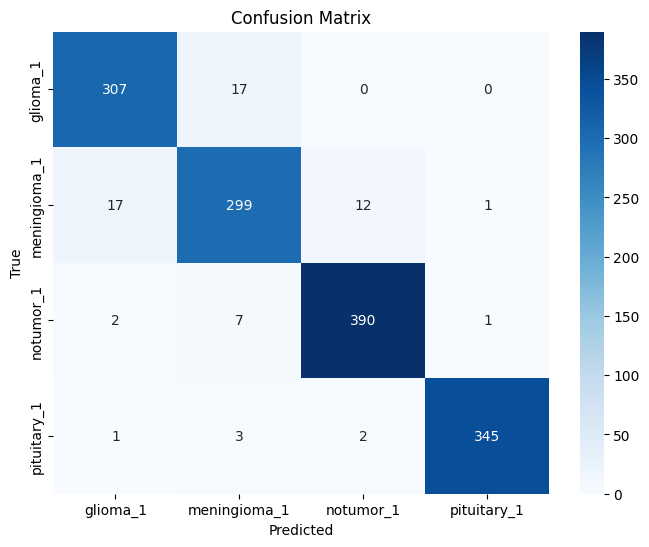

In [ ]:
import os
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import MobileNetV2  # Replace this with your chosen CNN model



def load_and_prep_image(filename, img_shape=500):
  """
  Reads an image from filename, turns it into a tensor
  and reshapes it to (img_shape, img_shape, colour_channel).
  """
  # Read in target file (an image)
  img = tf.io.read_file(filename)

  # Decode the read file into a tensor & ensure 3 colour channels
  # (our model is trained on images with 3 colour channels and sometimes images have 4 colour channels)
  img = tf.image.decode_image(img, channels=3)

  # Resize the image (to the same size our model was trained on)
  img = tf.image.resize(img, size = [img_shape, img_shape])

  # Rescale the image (get all values between 0 and 1)
  img = img/255.
  return img



# Path to the directory containing your data
data_directory = '/content/dataset/val/'

# Get class names from folder names
class_names = sorted(os.listdir(data_directory))

# Mapping folder names to class labels
label_map = {class_name: i for i, class_name in enumerate(class_names)}

# Initialize lists to store true and predicted labels
true_labels = []
predicted_labels = []

# Iterate through the folders and files to generate labels and predictions
for class_label, class_name in enumerate(class_names):
    class_folder = os.path.join(data_directory, class_name)
    for file_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, file_name)
        img = image.load_img(img_path, target_size=(224, 224))  # Adjust target size as needed
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = img_array/255.
#         img_array = preprocess_input(img_array)  # Preprocess input based on the chosen model

        # Predict class label using your CNN model
        predictions = model_14.predict(img_array)
        predicted_class = np.argmax(predictions)

        # Assign true label based on folder name
        true_labels.append(class_label)
        predicted_labels.append(predicted_class)

# Convert lists to numpy arrays
true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# Compute confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Display the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Print classification report
from sklearn.metrics import confusion_matrix, classification_report
print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=test_data.class_indices.keys()))

Classification Report:
              precision    recall  f1-score   support

    glioma_1       0.94      0.95      0.94       324
meningioma_1       0.92      0.91      0.91       329
   notumor_1       0.97      0.97      0.97       400
 pituitary_1       0.99      0.98      0.99       351

    accuracy                           0.96      1404
   macro avg       0.95      0.95      0.95      1404
weighted avg       0.96      0.96      0.96      1404

